# Setup and Introduction


The goal of the notebook is to compare how distributed quantum computing approaches compare to their monolithic counterparts. To keep scaling behaviour consistent we choose an easy scalable circuit family, GHZ states.

The notebook is split into three main sections:

1. **Generating GHZ circuits** - We use GHZ circuits because they are simple and easy to follow, to expand your circuit you simple add one CNOT gate. This simplicity lets us focus on differences between monolithic and distributed approaches without having to worry about how our circuit effects our scaling.
2. **Validation** - We validate correctness by sampling GHZ circuits and checking expected outputs using two simulators:
   - Qiskit Aer (monolithic simulator)
   - Bosonic simulator (distributed simulator)
3. **Exploration** - After validation, we study scaling from two perspectives:
   - Circuit metrics: depth, gate counts, and related compiled-circuit characteristics
   - Hardware metrics: an execution-time model that includes practical hardware considerations

Lastly, for reference we will use the following notation:
- *$n$*: number of qubits
- "remote" or "cross-module" gates: two-qubit interactions whose endpoints lie in different modules (two qubit gates between qubits in different modules).


# GHZ Circuit Generator

Now that we have installed all dependencies and given an overview of the notebook content, we can start building our test circuit. We use a Greenberger-Horne-Zeilinger (GHZ) state generator. A GHZ state on $n$ qubits is defined as:

$$
\lvert \mathrm{GHZ}_n \rangle
=
\frac{1}{\sqrt{2}}
\left(
\lvert 00\ldots 0_n \rangle
+
\lvert 11\ldots 1_n \rangle
\right)
=
\frac{1}{\sqrt{2}}
\left(
\lvert 0 \rangle^{\otimes n}
+
\lvert 1 \rangle^{\otimes n}
\right).
$$

After measuring all qubits in the computational basis, the ideal outcome distribution is:

$$
\Pr(0^n) = \Pr(1^n) = \frac{1}{2},
\qquad
\Pr(x) = 0
\ \text{for all other bitstrings } x.
$$

The circuit that generates this state is simple and involves two steps:

1. Apply $H$ to qubit $0$.
2. Apply $\mathrm{CX}(0 \to i)$ for $i = 1, \dots, n-1$.


### GHZ Circuit (n=3)

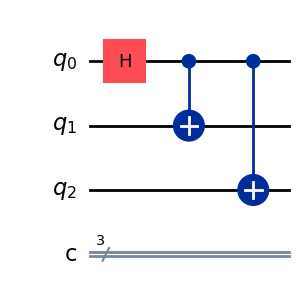

### GHZ Circuit (n=5)

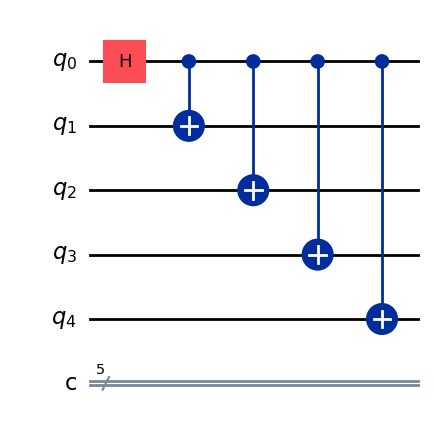

### GHZ Circuit (n=8)

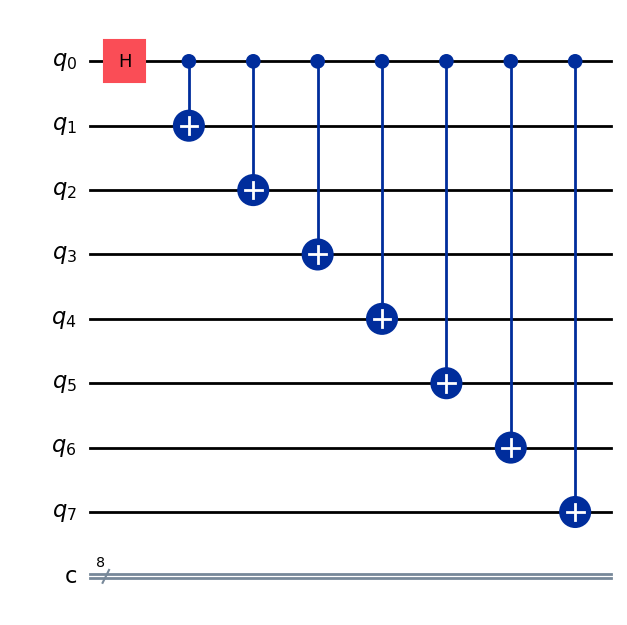

In [26]:
# Create GHZ circuits and visualize growth with n
from IPython.display import Markdown, display
from qiskit import QuantumCircuit

def ghz_circuit(n: int, measure: bool = True) -> QuantumCircuit:
    """Create a GHZ state circuit on n qubits."""
    qc = QuantumCircuit(n, n)
    qc.h(0)
    for i in range(1, n):
        qc.cx(0, i)
    if measure:
        qc.measure(range(n), range(n))
    return qc

for n in [3, 5, 8]:
    display(Markdown(f"### GHZ Circuit (n={n})"))
    display(ghz_circuit(n, measure=False).draw("mpl"))


# GHZ Config

We can see that the scaling of our GHZ circuit is pretty trivial. Now that we have our GHZ circuit function defined, the next task is to define some different circuit sizes which we want to explore. We define a list of circuit sizes measured in amount of qubits $n$ which we want to sweep over as well as some sampling parameters. We define the following adjustable parameters:

- **Circuit size sweep:** `N_LIST` contains the circuit sizes we want to evaluate.
- **Sampling:** `SHOTS` is the number of measurement samples per circuit.
- **Randomness:** `SEED` is a random seed for reproducibility.


## GHZ Config

Now that we have our GHZ circuit function defined, the next task is to define tunable knobs so we can simulate different scenarios and observe circuit behavior under different conditions. We define the following adjustable parameters:

- **Circuit size sweep:** `N_LIST` contains the circuit sizes we want to evaluate.
- **Module counts:** number of modules/QPUs used in distributed settings.
- **Sampling:** `SHOTS` is the number of measurement samples per circuit.
- **Randomness:** `SEED` is a random seed for reproducibility.


# Validating the Simulators

Now that we have defined our circuit, the next step to validate our simulators to ensure we are getting reliable results. To do this we run simulations and verify that we recover the expected GHZ outcomes.

We will use two simualtors in this notebook, one for a monolithic system and one for a distributed system. For our monolithic simulator we use the best available free simulator which is the IBM Sherbrooke simulator which simulates IBMs Heron chip. For our distributed simulator we use a Bosonic simulator which simulates a modular trapped ion system.

The simulators return measurement `counts` over `SHOTS` samples. For an ideal GHZ state, we expect roughly an equal amount of 0^n and 1^n measurements:

$$
\texttt{counts}[0^n] \approx \frac{\texttt{SHOTS}}{2},
\qquad
\texttt{counts}[1^n] \approx \frac{\texttt{SHOTS}}{2},
$$

and all other bitstrings should be zero .

We use these counts to define a simple fidelity proxy to ensure that we are measuring what we expect:

$$
\widehat{F}_{\mathrm{GHZ}}(n)
=
\frac{\texttt{counts}[0^n] + \texttt{counts}[1^n]}{\texttt{SHOTS}}.
$$

- $\widehat{F}_{\mathrm{GHZ}}(n) = 1$ means probability means we measured nothing but the expected bit strings and our simulators are working as intended.
- $\widehat{F}_{\mathrm{GHZ}}(n) \neq 1$ Indicate that we measured an incorrect bit string without any noise models this means that our simulators are not working as expected .

In the following cells, for each circuit size, we:
- run both simulator paths,
- print `count(0^n)` and `count(1^n)`,
- compute and plot the proxy scores.

We start by defining which circuit sizes we want to sweep over and testing the IBM simulator:


In [27]:
# Config
N_LIST = [3, 4, 6, 8, 10]  # Circuit Sizes to Sweep Over
SHOTS = 2048
SEED = 1234


In [28]:
# Monolithic validation path: transpile GHZ to Fake IBM hardware and simulate with Aer.
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
FAKE_IBM_BACKEND = FakeSherbrooke()
print(f'Using fake monolithic backend: FakeSherbrooke (num_qubits={FAKE_IBM_BACKEND.num_qubits})')

# Shared monolithic backend (used across notebook sections).
def compile_monolithic_ibm_fake(qc, optimization_level=3):
    """Transpile a logical circuit to an IBM-style hardware target."""
    return transpile(qc, backend=FAKE_IBM_BACKEND, optimization_level=optimization_level)

def print_monolithic_backend_diagnostics(qc_mono):
    """Workshop diagnostics: basis + connectivity + compiled complexity."""
    try:
        cfg = FAKE_IBM_BACKEND.configuration()
        basis_gates = cfg.basis_gates
        coupling_map_size = len(cfg.coupling_map)
    except Exception:
        basis_gates = sorted(list(getattr(FAKE_IBM_BACKEND, 'operation_names', [])))
        cmap = getattr(FAKE_IBM_BACKEND, 'coupling_map', None)
        coupling_map_size = len(cmap.get_edges()) if cmap is not None else 0
    print('Basis gates:', basis_gates)
    print('Coupling map size:', coupling_map_size)
    print('Monolithic depth:', qc_mono.depth())
    print('Monolithic ops:', qc_mono.count_ops())

def ghz_fidelity_proxy(counts, n, shots=None):
    shots = sum(counts.values()) if shots is None else shots
    return float('nan') if shots == 0 else (counts.get('0' * n, 0) + counts.get('1' * n, 0)) / shots

def run_aer_ghz(n, shots=SHOTS, seed=SEED):
    """Monolithic path: IBM-style transpile first, Aer simulation second."""
    qc = ghz_circuit(n)
    qc_mono = compile_monolithic_ibm_fake(qc)
    counts = (
        AerSimulator(method='automatic', seed_simulator=seed)
        .run(qc_mono, shots=shots)
        .result()
        .get_counts()
    )
    return counts, qc_mono
print('count(0^n) is all-zeros bitstring count; count(1^n) is all-ones bitstring count.')
for _n in N_LIST:
    _counts, _qc_mono = run_aer_ghz(_n, shots=SHOTS)
    _c0 = _counts.get('0' * _n, 0)
    _c1 = _counts.get('1' * _n, 0)
    _proxy = ghz_fidelity_proxy(_counts, _n, shots=sum(_counts.values()))
    print(f'[IBM-Fake-Sherbrooke] n={_n:2d} depth={_qc_mono.depth():3d} count(0^{_n})={_c0} count(1^{_n})={_c1} proxy={_proxy:.3f}')


Using fake monolithic backend: FakeSherbrooke (num_qubits=127)
count(0^n) is all-zeros bitstring count; count(1^n) is all-ones bitstring count.
[IBM-Fake-Sherbrooke] n= 3 depth= 12 count(0^3)=1009 count(1^3)=1039 proxy=1.000
[IBM-Fake-Sherbrooke] n= 4 depth= 18 count(0^4)=1031 count(1^4)=1017 proxy=1.000
[IBM-Fake-Sherbrooke] n= 6 depth= 39 count(0^6)=1031 count(1^6)=1017 proxy=1.000
[IBM-Fake-Sherbrooke] n= 8 depth= 62 count(0^8)=1031 count(1^8)=1017 proxy=1.000
[IBM-Fake-Sherbrooke] n=10 depth=101 count(0^10)=1031 count(1^10)=1017 proxy=1.000


### Next, we run the same circuit on the Bosonic simulator


In [29]:
from bosonic_converters import CircuitConverters
from bosonic_sdk import BosonicDistributor, Simulator


In [30]:
import math

def module_count(n, qubits_per_module):
    """Minimum module count needed to host n qubits at fixed capacity."""
    return max(1, math.ceil(int(n) / int(qubits_per_module)))

def compile_bosonic_circuit(qc, n, k_modules):
    """Distribute a Qiskit circuit across Bosonic modules and return a Qiskit circuit."""
    internal = CircuitConverters.from_qiskit(qc)
    modules = max(1, int(k_modules))
    ions_per_trap = max(1, math.ceil(int(n) / modules))
    distributed = BosonicDistributor().distribute(
        internal,
        nodes=modules,
        qubits_per_node=ions_per_trap,
    )
    return CircuitConverters.to_qiskit(distributed.as_monolithic_circuit())


In [31]:
def run_bosonic_ghz(n, shots=SHOTS, traps=2):
    qc = ghz_circuit(n)
    tqc = compile_bosonic_circuit(qc, n, traps)
    counts, _ = Simulator().run_counts(tqc.copy(), ignore_c_remote=True, shots=shots)
    return counts, tqc
print(f'Note that count(0^{{n}}) here refers to the count of the bitstring with n zeros, and count(1^{{n}}) refers to the count of the bitstring with n ones.')
for _n in N_LIST:
    try:
        _counts, _ = run_bosonic_ghz(_n, shots=SHOTS, traps=2)
        _c0 = _counts.get('0' * _n, 0)
        _c1 = _counts.get('1' * _n, 0)
        _proxy = ghz_fidelity_proxy(_counts, _n, shots=sum(_counts.values()))
        print(f'[Bosonic] n={_n:2d} count(0^{_n})={_c0} count(1^{_n})={_c1} proxy={_proxy:.3f}')
    except Exception as e:
        print(f'[Bosonic] n={_n:2d} ERROR: {e}')


Note that count(0^{n}) here refers to the count of the bitstring with n zeros, and count(1^{n}) refers to the count of the bitstring with n ones.
[Bosonic] n= 3 count(0^3)=1047 count(1^3)=1001 proxy=1.000
[Bosonic] n= 4 count(0^4)=1016 count(1^4)=1032 proxy=1.000
[Bosonic] n= 6 count(0^6)=1015 count(1^6)=1033 proxy=1.000
[Bosonic] n= 8 count(0^8)=1023 count(1^8)=1025 proxy=1.000
[Bosonic] n=10 count(0^10)=1010 count(1^10)=1038 proxy=1.000


### Now we graph the fidelity proxy score to visualize how simulator correctness scales with circuit size


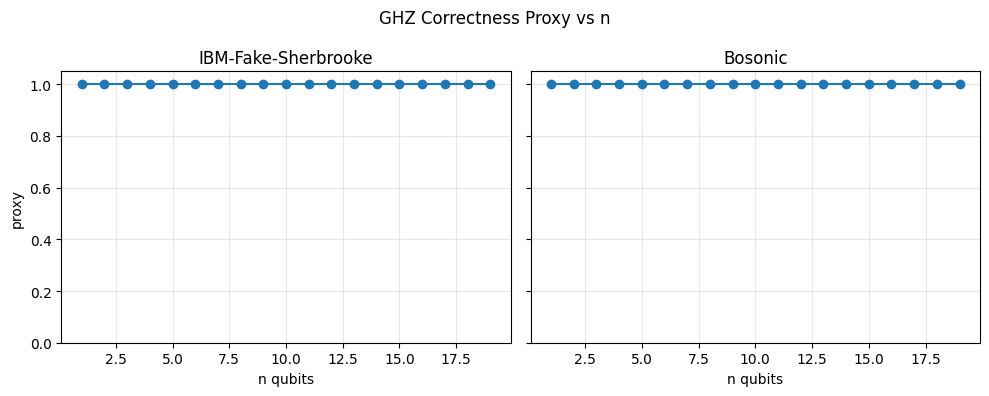

In [32]:
# Compare fidelity proxy for monolithic vs Bosonic paths across N_LIST.
import pandas as pd
import matplotlib.pyplot as plt
proxy_records = []
shots_eval = min(SHOTS, 512)

# Initialize list to hold proxy records and set evaluation shots
for _n in range(1,20):
    counts_mono, _ = run_aer_ghz(_n, shots=shots_eval, seed=SEED)
    proxy_records.append({'n': _n, 'backend': 'IBM-Fake-Sherbrooke', 'proxy': ghz_fidelity_proxy(counts_mono, _n, shots=sum(counts_mono.values()))})
# Compute the proxy score for each backend
    try:
        counts_bos, _ = run_bosonic_ghz(_n, shots=shots_eval, traps=2)
        proxy_records.append({'n': _n, 'backend': 'Bosonic', 'proxy': ghz_fidelity_proxy(counts_bos, _n, shots=sum(counts_bos.values()))})
    except Exception:
        proxy_records.append({'n': _n, 'backend': 'Bosonic', 'proxy': float('nan')})
df_proxy = pd.DataFrame(proxy_records)
_fig, _axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for _ax, backend in zip(_axes, ['IBM-Fake-Sherbrooke', 'Bosonic']):
    _sub = df_proxy[df_proxy['backend'] == backend]
    _ax.plot(_sub['n'], _sub['proxy'], marker='o')
    _ax.set_title(backend)
    _ax.set_xlabel('n qubits')
    _ax.set_ylim(0, 1.05)
    _ax.grid(True, alpha=0.3)
_axes[0].set_ylabel('proxy')
_fig.suptitle('GHZ Correctness Proxy vs n')
plt.tight_layout()
# Graph each proxy score
plt.show()


# Circuit Metrics with Scaling Circuit Size

Now that we have verified that our simulators are behaving as expected, we can explore scaling complexity between our monolithic baseline and distributed baseline as circuit size grows.

For now we will focus on the following metrics (but you can look at other metrics later):
- `depth`: longest sequential gate path (time-step count)
- `two_qubit_depth`: longest chain of explicit two-qubit-operation layers
- `two_qubit_count`: total number of two-qubit operations
- `total_ops`: total operation count

Going up in 5's for each $n$, we:

1. Build the logical GHZ circuit ghz_circuit(n).
2. Compile and measure monolithic metrics.
3. Compile and measure distributed metrics with dynamic module count (`k = ceil(n / 20)`).
4. Plot each metric versus `n` to compare growth trends.

To keep the comparison fair, we use a single metric engine (`GateStatistics.stats`) for both paths so metric definitions stay consistent. The source is under `qiskit-transpiler/gate_statistics.py`.


In [33]:
def plot_metric_grid(
    df,
    metric_pairs,
    scenario_order,
    scenario_labels,
    title,
    y_label_mode='fixed',
    fixed_y_label='value',
):
    n_metrics = len(metric_pairs)
    ncols = 2
    nrows = math.ceil(n_metrics / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = [axes] if n_metrics == 1 else axes.flatten()
    for ax, (metric, metric_title) in zip(axes, metric_pairs):
        for scenario in scenario_order:
            sub = df[df['scenario'] == scenario].sort_values('n')
            if sub.empty:
                continue
            ax.plot(sub['n'], sub[metric], marker='o', label=scenario_labels[scenario])
        ax.set_title(metric_title)
        ax.set_xlabel('n qubits')
        ax.set_ylabel(metric if y_label_mode == 'metric' else fixed_y_label)
        ax.grid(True, alpha=0.3)
    for ax in axes[n_metrics:]:
        ax.set_visible(False)
    axes[0].legend()
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_two_series_by_scenario(
    df,
    scenario_order,
    scenario_labels,
    left_col,
    right_col,
    left_title,
    right_title,
    left_ylabel,
    right_ylabel,
    status_col=None,
    status_ok_value='ok',
):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
    for scenario in scenario_order:
        sub = df[df['scenario'] == scenario].sort_values('n')
        if status_col is not None:
            sub = sub[sub[status_col] == status_ok_value]
        if sub.empty:
            continue
        label = scenario_labels[scenario]
        axes[0].plot(sub['n'], sub[left_col], marker='o', label=label)
        axes[1].plot(sub['n'], sub[right_col], marker='o', label=label)
    axes[0].set_title(left_title)
    axes[0].set_xlabel('n qubits')
    axes[0].set_ylabel(left_ylabel)
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].set_title(right_title)
    axes[1].set_xlabel('n qubits')
    axes[1].set_ylabel(right_ylabel)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    plt.tight_layout()
    plt.show()


In [34]:
from bosonic_sdk.gate_statistics import GateStatistics
PLOT_METRICS = [('depth', 'Depth'), ('two_qubit_depth', 'Two-Qubit Layer Depth'), ('two_qubit_count', 'Two-Qubit Gate Count'), ('total_ops', 'Total Ops')]
N_LIST_1 = list(range(5, 126, 5))
QUBITS_PER_TRAP = 20

def distributed_module_count(n, qubits_per_module=QUBITS_PER_TRAP):
    """Minimum modules needed to host n qubits with fixed module capacity."""
    return module_count(n, qubits_per_module)

def qiskit_structural_metrics(qc):
    """Derive gate counts/depth metrics directly from a transpiled Qiskit circuit."""
    one_q = 0
    two_q = 0
    multi_q = 0
    measure_count = 0
    reset_count = 0
    barrier_count = 0
    layer_by_qubit = {}
    two_qubit_depth = 0
    for inst in qc.data:
        op = inst.operation
        name = op.name
        n_qubits = len(inst.qubits)
        if name == 'measure':
            measure_count = measure_count + 1
            continue
        if name == 'reset':
            reset_count = reset_count + 1
            continue
        if name == 'barrier':
            barrier_count = barrier_count + 1
            continue
        if n_qubits == 1:
            one_q = one_q + 1
        elif n_qubits == 2:
            two_q = two_q + 1
            layer = 1 + max((layer_by_qubit.get(q, 0) for q in inst.qubits), default=0)
            for q in inst.qubits:
                layer_by_qubit[q] = layer
            two_qubit_depth = max(two_qubit_depth, layer)
        elif n_qubits > 2:
            multi_q = multi_q + 1
    return {'single_qubit_count': one_q, 'two_qubit_count': two_q, 'multi_qubit_count': multi_q, 'two_qubit_depth': two_qubit_depth, 'measure_count': measure_count, 'reset_count': reset_count, 'barrier_count': barrier_count}


METRIC_REGISTRY = {'n_qubits': lambda s, g, q: s['n_qubits'], 'n_clbits': lambda s, g, q: s['n_clbits'], 'total_ops': lambda s, g, q: s['total_ops'], 'depth': lambda s, g, q: s['depth'], 'gate_counts': lambda s, g, q: s['gate_counts'], 'basis_gates': lambda s, g, q: s['basis_gates'], 'measure_count': lambda s, g, q: q['measure_count'], 'reset_count': lambda s, g, q: q['reset_count'], 'barrier_count': lambda s, g, q: q['barrier_count'], 'local_gate_count': lambda s, g, q: s['local_gate_count'], 'remote_gate_count': lambda s, g, q: s['remote_gate_count'], 'total_remote_gates': lambda s, g, q: s['total_remote_gates'], 'qubit_teleportation_count': lambda s, g, q: s['qubit_teleportation_count'], 'n_classical_gates': lambda s, g, q: s['n_classical_gates'], 'single_qubit_count': lambda s, g, q: q['single_qubit_count'], 'two_qubit_count': lambda s, g, q: q['two_qubit_count'], 'multi_qubit_count': lambda s, g, q: q['multi_qubit_count'], 'two_qubit_depth': lambda s, g, q: q['two_qubit_depth'], 'remote_link_count': lambda s, g, q: g.get('remote_link_psi_minus', 0) + g.get('remote_link_psi_plus', 0)}

def extract_metrics(qc, metric_registry, metric_pairs):
    stats = GateStatistics.stats(CircuitConverters.from_qiskit(qc))
    gate_counts = stats['gate_counts']
    qiskit_metrics = qiskit_structural_metrics(qc)
    out = {}
    for key, _ in metric_pairs:
        if key not in metric_registry:
            raise ValueError(f'Unknown metric key: {key}. Double Check to make sure desired metric is in the Registry')
        value = metric_registry[key](stats, gate_counts, qiskit_metrics)
        out[key] = value
    return out

def selected_gate_metrics(qc, metric_pairs=PLOT_METRICS):
    """Extract only the metrics selected in PLOT_METRICS."""
    return extract_metrics(qc, METRIC_REGISTRY, metric_pairs)


In [35]:
_records = []
for _n in N_LIST_1:
    _qc = ghz_circuit(_n)
    _qc_mono = compile_monolithic_ibm_fake(_qc)
    _m_mono = selected_gate_metrics(_qc_mono, metric_pairs=PLOT_METRICS)
    _records.append({'scenario': 'monolithic', 'backend': 'IBM-Fake-Sherbrooke', 'n': _n, 'k': 1, **_m_mono})
    _k_dist = distributed_module_count(_n)
    tqc_bos = compile_bosonic_circuit(_qc, _n, _k_dist)
    m_bos = selected_gate_metrics(tqc_bos, metric_pairs=PLOT_METRICS)
    _records.append({'scenario': 'distributed', 'backend': 'Bosonic (128 qubits/module)', 'n': _n, 'k': _k_dist, **m_bos})
df_complexity = pd.DataFrame(_records)
df_complexity
compile_bosonic = compile_bosonic_circuit


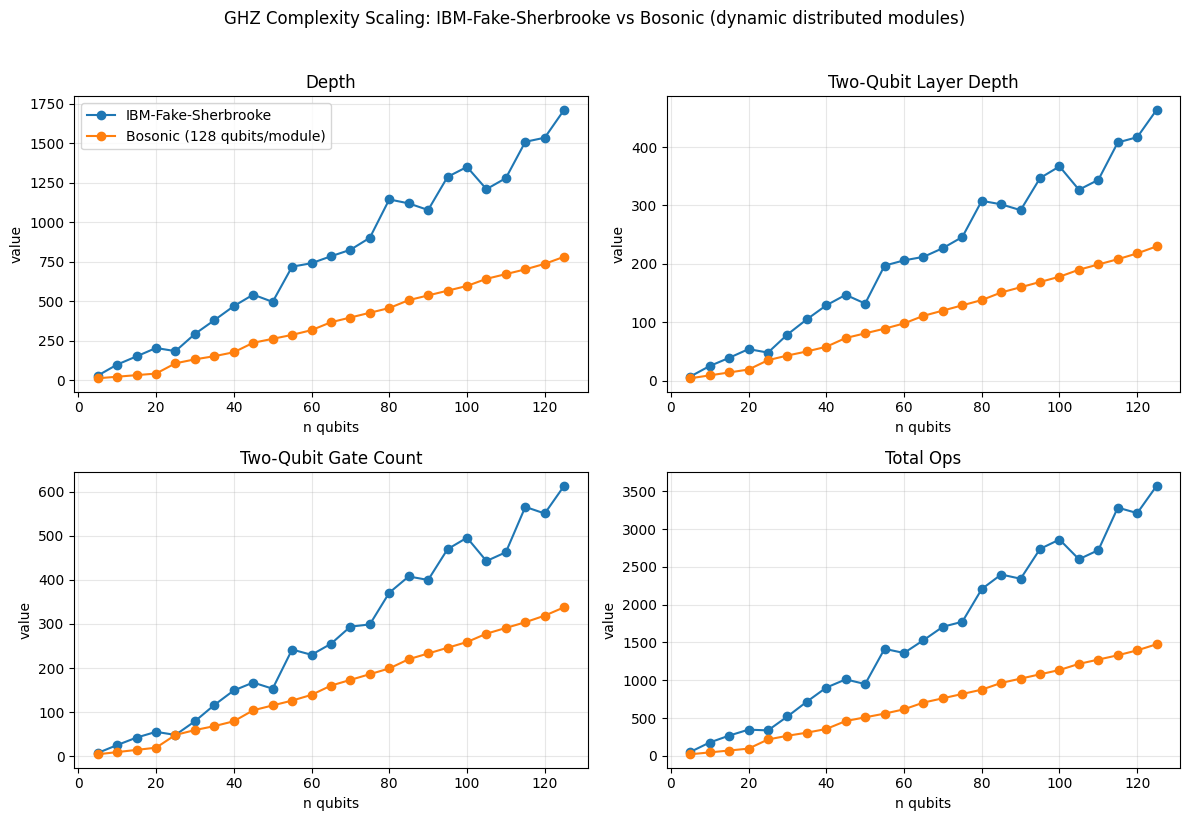

In [36]:
plot_metric_grid(
    df_complexity,
    metric_pairs=PLOT_METRICS,
    scenario_order=['monolithic', 'distributed'],
    scenario_labels={
        'monolithic': 'IBM-Fake-Sherbrooke',
        'distributed': 'Bosonic (128 qubits/module)',
    },
    title='GHZ Complexity Scaling: IBM-Fake-Sherbrooke vs Bosonic (dynamic distributed modules)',
)


# Interpreting the Results

Quantum computation is expensive and error-prone, so we generally want to do as little quantum computation as we can. This means we want circuits with fewer operations and shallower paths.

Two-qubit gates are especially important because they are typically slower and noisier than single-qubit gates. That is why we choose `two_qubit_count` and `two_qubit_depth` as our measured metrics.

Connectivity is the biggest culprit for this scaling behaviour. In monolithic nearest-neighbor hardware, non-local interactions require routing through SWAP operations. This routing overhead increases depth and total operation count as circuits grows. In the distributed approach we still have to worry about connectivity but due to having modules as opposed to one big chip scaling is much more managable.


--------------------------------------------------------------------------------------------------------------------------------------

# Executing on Real Hardware

So far we have seen how scaling affects the circuit we are implementing. This is useful for building intuition, but what we are really interested in is what execution on real hardware might look like. Accessing real hardware involves provider cost, queue times, and cloud submission overhead. That is worthwhile when we care about running an application circuit, but for the purposes of exploring scaling dynamics it is quite unnessecary. We instead opt to build a simple model for execution time or 'time to solution' that incorporates the metrics we care about.

To begin, we treat a compiled circuit as a collection of single-qubit gates and two-qubit gates. Different gate types can have different execution times, but for a simpler model we assume an average single-qubit gate time $t_{1q}$ and an average two-qubit gate time $t_{2q}$. Under that assumption, one shot of the circuit takes:

$$
T_{\text{shot}}(n)=t_{1q}N_{1q}(n) + t_{2q}N_{2q}(n)
$$

We also assume that measurement takes time $t_{\text{measure}}$ per qubit, and we include an overhead term for classical control, reset, and other per-shot orchestration costs. Our time per shot then becomes:

$$
T_{\text{shot}}(n)=t_{1q}N_{1q}(n) + t_{2q}N_{2q}(n) + t_{\text{measure}}n + t_{\text{overhead}}.
$$

where:
- $t_{1q}$ is the execution time of a single-qubit gate
- $N_{1q}$ is the number of compiled single-qubit gates
- $t_{2q}$ is the execution time of a two-qubit gate
- $N_{2q}$ is the number of compiled two-qubit gates
- $t_{\text{measure}}$ is the measurement time per qubit
- $t_{\text{overhead}}$ is the per-shot overhead for classical control and reset
- $n$ is the circuit size in number of qubits

This gives us a model for the cost of executing the circuit once. However, we typically want to run many shots. If we need $S$ shots, then a simple time-to-solution model multiplies the per-shot cost by the number of required shots.

$$
\mathrm{TTS}(n,k) \approx {S}*T_{\text{shot}}(n).
$$

Lastly we have to take into account error. The circuits we are testing do not include self-correcting error codes, this means that on real hardware each shot only succeeds with some probability. We will take a look at what circuits with error correcting codes look like later but for our model we assume that the success probability of the full circuit is the product of the success probabilities of the gates that make it up:

$$
P_{\text{success}}(n)=
(1-\epsilon_{1q})^{N_{1q}(n)}
(1-\epsilon_{2q})^{N_{2q}(n)}.
$$

where:
- $\epsilon_{1q}$ is the error rate of a single-qubit gate
- $\epsilon_{2q}$ is the error rate of a two-qubit gate
- $N_{1q}(n)$ is the number of single-qubit gates in the compiled circuit
- $N_{2q}(n)$ is the number of two-qubit gates in the compiled circuit

If only a fraction $P_{\text{success}}$ of shots succeed, then the effective time-to-solution increases by a factor of $1/P_{\text{success}}$. Using that correction, the success-adjusted model becomes:

$$
\mathrm{TTS}(n,k) \approx
{S} *
\frac{T_{\text{shot}}(n)}{P_{\text{success}}(n)}.
$$

We start by defining the hardware parameters used in this model.


In [37]:
# Model Configuration, here we choose all of the parameters we will use in our model.
SHOTS_2 = 1024
N_LIST_2 = list(range(5, 126, 5))
SCENARIOS = ['monolithic', 'distributed']  # sample every 5 qubits up to 125 for cleaner/faster sweeps
QUBITS_PER_TRAP_1 = 128
IBM_STYLE_TIMING = {'t1q': 2e-08, 't2q': 2e-07, 't_meas': 1e-06, 't_overhead': 0.0002, 'e1q': 0.0005, 'e2q': 0.003}
# Scenario setup
TRAPPED_ION_TIMING = {'t1q': 1e-06, 't2q': 3e-05, 't_meas': 0.0004, 't_overhead': 0.001, 'e1q': 1e-06, 'e2q': 0.0001}
P_SUCCESS_FLOOR = 1e-300  # Bosonic capacity per trap
TTS_PLOT_MAX = 1000000000000.0
GROWTH_SWEEP_MAX_N = 126
# Hardware parameters for the time to soluttion models. Numbers are taken from real data and are meant to give an honest estimate. 
# Guardrails to avoid overflow errors 
# Maximum for time to solution plot, note that 1e12 seconds is about 31,700 years, no one is living that long
# Settings for transpillation, these are the optimization levels used when transpilling our circuits, since we are not printing the circuits 
# and just considering the gate growth we have minimal optimization to avoid long compute times
IBM_OPT_LEVEL_GROWTH = 1


### With our metrics defined, we now implement helper functions for each equation component and evaluate the model for each circuit size and hardware scenario.


In [38]:
def distributed_trap_count(n, qubits_per_trap=QUBITS_PER_TRAP_1):
    """Minimum traps needed so each trap holds <= qubits_per_trap."""
    return module_count(n, qubits_per_trap)

def timing_profile_for_scenario(scenario):
    """Monolithic uses IBM-style profile; distributed uses trapped-ion profile."""
    if scenario == 'monolithic':
        return IBM_STYLE_TIMING
    return TRAPPED_ION_TIMING

def gate_counts(qc):
    """Count effective 1Q, 2Q, and measurement operations from a compiled circuit."""
    ops = qc.count_ops()
    one_q = {'x', 'y', 'z', 'h', 's', 'sdg', 't', 'tdg', 'rx', 'ry', 'rz', 'sx', 'sxdg', 'u', 'u1', 'u2', 'u3', 'p'}
    two_q = {'cx', 'cz', 'ecr', 'swap', 'iswap', 'rzz', 'rxx', 'ryy', 'remote_link_psi_minus', 'remote_link_psi_plus'}
    n1 = sum((ops.get(g, 0) for g in one_q))
    n2 = sum((ops.get(g, 0) for g in two_q))
    n_meas = int(ops.get('measure', 0))
    covered = one_q | two_q | {'measure', 'reset', 'barrier', 'delay', 'if_else'}
    for inst in qc.data:
        if inst.operation.name in covered:
            continue
        if inst.operation.num_qubits == 1:
            n1 = n1 + 1
        elif inst.operation.num_qubits == 2:
            n2 = n2 + 1
    return (int(n1), int(n2), int(n_meas))

def shot_success_probability(N1, N2, scenario='monolithic'):
    """Independent-gate success proxy from 1Q/2Q error rates."""
    prof = timing_profile_for_scenario(scenario)
    e1 = max(0.0, min(1.0 - 1e-15, float(prof['e1q'])))
    e2 = max(0.0, min(1.0 - 1e-15, float(prof['e2q'])))
    log_p = float(N1) * math.log1p(-e1) + float(N2) * math.log1p(-e2)
    log_floor = math.log(max(P_SUCCESS_FLOOR, 1e-320))
    return float(math.exp(max(log_p, log_floor)))

def T_shot_from_counts(N1, N2, N_meas=0, scenario='monolithic'):
    prof = timing_profile_for_scenario(scenario)
    t_compute = prof['t1q'] * N1 + prof['t2q'] * N2 + prof['t_meas'] * N_meas
    return t_compute + prof['t_overhead']

def TTS_from_shots(T_shot, p_success=1.0, shots=SHOTS_2):
    """Success-adjusted time to solution for serial shots with log-domain stabilization."""
    p_eff = max(float(p_success), P_SUCCESS_FLOOR)
    t_eff = max(float(T_shot), 1e-320)
    log_tts = math.log(t_eff) + math.log(float(shots)) - math.log(p_eff)
    return float(math.exp(min(log_tts, math.log(1e+300))))

def compile_for_shot_model(n, scenario='monolithic', module_count_for_distributed=1):
    """Build and compile GHZ for the selected scenario."""
    qc = ghz_circuit(n)
    if scenario == 'monolithic':
        qc_mono = compile_monolithic_ibm_fake(qc)
        if not getattr(compile_for_shot_model, '_printed_diag', False):
            print_monolithic_backend_diagnostics(qc_mono)
            compile_for_shot_model._printed_diag = True
        return qc_mono
    module_count_value = max(1, int(module_count_for_distributed))
    return compile_bosonic(qc, n, module_count_value)

def tts_row_defaults(n, scenario, k_modules):
    return {
        'n': n,
        'scenario': scenario,
        'label': 'Monolithic (IBM fake)' if scenario == 'monolithic' else 'Distributed (Bosonic, traps=ceil(n/128))',
        'k_modules': k_modules,
        'backend': 'IBM-Fake-Sherbrooke' if scenario == 'monolithic' else f'Bosonic (k={k_modules})',
    }

def build_tts_row(n, scenario, k_modules, qc_comp=None, exc=None):
    row = tts_row_defaults(n, scenario, k_modules)
    if exc is not None:
        row.update({
            'N1': float('nan'),
            'N2': float('nan'),
            'N_meas': float('nan'),
            't1q': float('nan'),
            't2q': float('nan'),
            't_meas': float('nan'),
            't_overhead': float('nan'),
            'e1q': float('nan'),
            'e2q': float('nan'),
            'P_success': float('nan'),
            'T_shot_compute': float('nan'),
            'T_shot_overhead': float('nan'),
            'T_shot': float('nan'),
            'TTS_shots_ideal': float('nan'),
            'TTS_shots': float('nan'),
            'total_ops': float('nan'),
            'depth': float('nan'),
            'status': f'failed: {exc.__class__.__name__}',
        })
        return row
    N1, N2, N_meas = gate_counts(qc_comp)
    prof = timing_profile_for_scenario(scenario)
    p_success = shot_success_probability(N1, N2, scenario=scenario)
    t_shot_compute = prof['t1q'] * N1 + prof['t2q'] * N2 + prof['t_meas'] * N_meas
    t_shot_overhead = prof['t_overhead']
    t_shot = T_shot_from_counts(N1, N2, N_meas=N_meas, scenario=scenario)
    tts_ideal = SHOTS_2 * t_shot
    tts = TTS_from_shots(t_shot, p_success=p_success, shots=SHOTS_2)
    row.update({
        'N1': N1,
        'N2': N2,
        'N_meas': N_meas,
        't1q': prof['t1q'],
        't2q': prof['t2q'],
        't_meas': prof['t_meas'],
        't_overhead': prof['t_overhead'],
        'e1q': prof['e1q'],
        'e2q': prof['e2q'],
        'P_success': p_success,
        'T_shot_compute': t_shot_compute,
        'T_shot_overhead': t_shot_overhead,
        'T_shot': t_shot,
        'TTS_shots_ideal': tts_ideal,
        'TTS_shots': tts,
        'total_ops': int(sum(qc_comp.count_ops().values())),
        'depth': int(qc_comp.depth()),
        'status': 'ok',
    })
    return row


In [ ]:
import pandas as pd
_tts_records = []
for _n in N_LIST_2:
    for _scenario in SCENARIOS:
        _k_modules = 1 if _scenario == 'monolithic' else distributed_trap_count(_n)
        try:
            _qc_comp = compile_for_shot_model(_n, scenario=_scenario, module_count_for_distributed=_k_modules)
            _tts_records.append(build_tts_row(_n, _scenario, _k_modules, qc_comp=_qc_comp))
        except Exception as e:
            _tts_records.append(build_tts_row(_n, _scenario, _k_modules, exc=e))
df_tts = pd.DataFrame(_tts_records)



Basis gates: ['ecr', 'id', 'rz', 'sx', 'x']
Coupling map size: 144
Monolithic depth: 28
Monolithic ops: OrderedDict([('rz', 32), ('sx', 19), ('ecr', 7), ('measure', 5)])
Sanity: main comparison uses serial shots only.
Sanity: distributed machine module counts use ceil sizing rule (sample) = [{'n': 5, 'k_modules': 1}, {'n': 10, 'k_modules': 1}, {'n': 15, 'k_modules': 1}, {'n': 20, 'k_modules': 1}, {'n': 25, 'k_modules': 1}]


In [16]:
_records = []
for _n in N_LIST_2:
    for _scenario in SCENARIOS:
        _k_modules = 1 if _scenario == 'monolithic' else distributed_trap_count(_n)
        try:
            qc_comp = compile_for_shot_model(_n, scenario=_scenario, module_count_for_distributed=_k_modules)
            _records.append(build_tts_row(_n, _scenario, _k_modules, qc_comp=qc_comp))
        except Exception as exc:
            _records.append(build_tts_row(_n, _scenario, _k_modules, exc=exc))
df_tts = pd.DataFrame(_records)


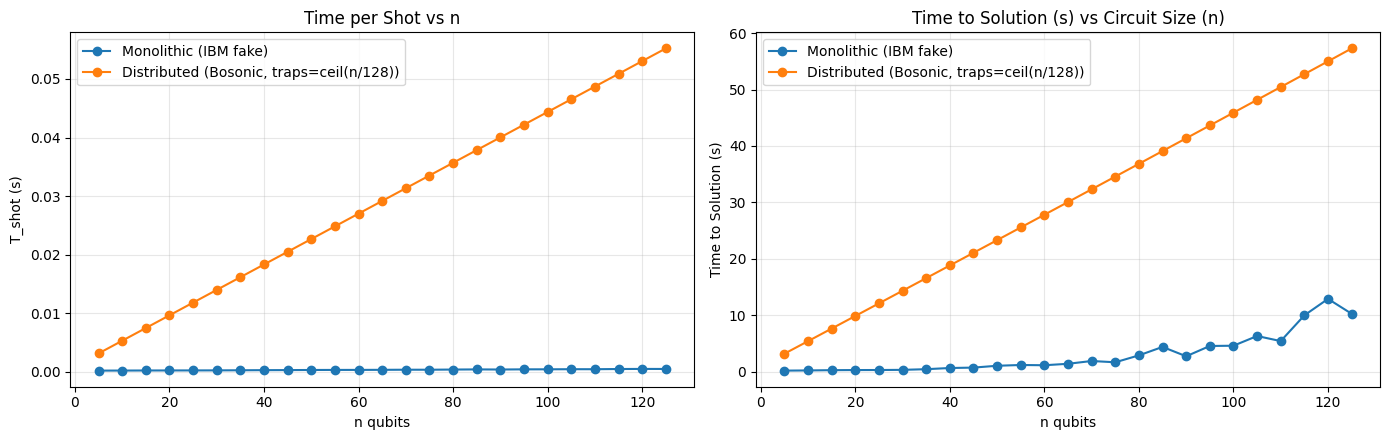

In [17]:
plot_two_series_by_scenario(
    df_tts,
    scenario_order=['monolithic', 'distributed'],
    scenario_labels={
        'monolithic': 'Monolithic (IBM fake)',
        'distributed': 'Distributed (Bosonic, traps=ceil(n/128))',
    },
    left_col='T_shot',
    right_col='TTS_shots',
    left_title='Time per Shot vs n',
    right_title='Time to Solution (s) vs Circuit Size (n)',
    left_ylabel='T_shot (s)',
    right_ylabel='Time to Solution (s)',
    status_col='status',
)


# Interpretation

Let's interpret the two plots together.

At first glance, monolithic IBM-style hardware appears to have much lower time to solution. However, you may notice that as we approach ~110 qubits we see a sharper rise in the monolithic system wheras the distributed system stays consistent.

Recall that in the earlier gate analysis we saw that the amount of gates needed in the monolithic system was larger for monolithic systems as well. This suggests that as we grow in circuit size monolithic systems might have a harder time scaling up.

This matters because useful fault-tolerant workloads are expected in regimes far beyond today's small demonstrations, often requiring thousands to tens of thousands of physical qubits depending on the algorithm and error-correction assumptions.


# Extrapolating to Useful Circuit Sizes

The IBM device caps out at 127 qubits, to get around this and avoid expensive simulation we can use the data we have from our current simulation and assume that we would see a similar pattern as we extent to utility scale regimes (assuming that the IBM chip would have the same structure but grow in qubit counts).

The graphs suggest we see a linear increase in gate counts between monolithic and distributed system. Assuming we continue to scale linearly we can use a line of best fit to extrapolate to the utility scale regime we want to explore.

For each scenario (`monolithic`, `distributed`), we:
1. fit linear trends on transpiled points:
   - `N1(n) ~ a1 * n + b1`
   - `N2(n) ~ a2 * n + b2`
2. Use projected `N1, N2, N_meas` in the same TTS model.
3. Plot projected complexity and projected `TTS_shots` on log scales.


In [18]:
import numpy as np
N_EXTRAP = np.unique(np.logspace(0, 5, 24).astype(int)).tolist()

def fit_linear(n_vals, y_vals):
    _n = np.asarray(n_vals, dtype=float)
    y = np.asarray(y_vals, dtype=float)
    mask = np.isfinite(_n) & np.isfinite(y)
    _n = _n[mask]
    y = y[mask]
    if _n.size < 2:
        return None
    a, b = np.polyfit(_n, y, 1)
    return (float(a), float(b))

def predict_linear(n_vals, params):
    if params is None:
        return np.full(len(n_vals), np.nan)
    a, b = params
    _n = np.asarray(n_vals, dtype=float)
    return a * _n + b
rows = []
n_growth_list = list(range(2, GROWTH_SWEEP_MAX_N + 1))
for _n in n_growth_list:
    qc = ghz_circuit(_n)
    qc_ibm = compile_monolithic_ibm_fake(qc, optimization_level=IBM_OPT_LEVEL_GROWTH)
    N1_i, N2_i, Nm_i = gate_counts(qc_ibm)
    rows.append({'n': _n, 'scenario': 'monolithic', 'label': f'IBM FakeSherbrooke (opt={IBM_OPT_LEVEL_GROWTH})', 'N1': N1_i, 'N2': N2_i, 'N_meas': Nm_i})
    k_growth = distributed_trap_count(_n)
    qc_bos = compile_bosonic(qc, _n, k_growth)
    N1_b, N2_b, Nm_b = gate_counts(qc_bos)
    rows.append({'n': _n, 'scenario': 'distributed', 'label': f'Bosonic (traps=ceil(n/{QUBITS_PER_TRAP_1}))', 'N1': N1_b, 'N2': N2_b, 'N_meas': Nm_b})
df_growth_sweep = pd.DataFrame(rows)

fit_rows = []
proj_rows = []
for scenario in ['monolithic', 'distributed']:
    sub = df_growth_sweep[df_growth_sweep['scenario'] == scenario].sort_values('n')
    p1 = fit_linear(sub['n'].values, sub['N1'].values)
    p2 = fit_linear(sub['n'].values, sub['N2'].values)
    pm = fit_linear(sub['n'].values, sub['N_meas'].values)
    fit_rows.append({
        'scenario': scenario,
        'N1_slope': np.nan if p1 is None else p1[0],
        'N1_intercept': np.nan if p1 is None else p1[1],
        'N2_slope': np.nan if p2 is None else p2[0],
        'N2_intercept': np.nan if p2 is None else p2[1],
        'Nmeas_slope': np.nan if pm is None else pm[0],
        'Nmeas_intercept': np.nan if pm is None else pm[1],
    })
    n_proj = np.array(N_EXTRAP, dtype=float)
    n1_proj = np.maximum(predict_linear(n_proj, p1), 0.0)
    n2_proj = np.maximum(predict_linear(n_proj, p2), 0.0)
    nm_proj = np.maximum(predict_linear(n_proj, pm), 0.0)
    for _n_val, _n1_hat, _n2_hat, _nm_hat in zip(n_proj, n1_proj, n2_proj, nm_proj):
        _k_modules = 1 if scenario == 'monolithic' else distributed_trap_count(_n_val)
        p_succ_hat = shot_success_probability(_n1_hat, _n2_hat, scenario=scenario)
        t_shot_hat = T_shot_from_counts(_n1_hat, _n2_hat, N_meas=_nm_hat, scenario=scenario)
        tts_ideal_hat = SHOTS_2 * t_shot_hat
        tts_hat = TTS_from_shots(t_shot_hat, p_success=p_succ_hat, shots=SHOTS_2)
        proj_rows.append({
            'n': int(_n_val),
            'scenario': scenario,
            'k_modules': int(_k_modules),
            'N1_hat': float(_n1_hat),
            'N2_hat': float(_n2_hat),
            'N_meas_hat': float(_nm_hat),
            'P_success_hat': float(p_succ_hat),
            'T_shot_hat': float(t_shot_hat),
            'TTS_shots_ideal_hat': float(tts_ideal_hat),
            'TTS_shots_hat': float(tts_hat),
        })
df_fit = pd.DataFrame(fit_rows)
df_proj = pd.DataFrame(proj_rows)


### We now plot extrapolated results on log-log axes. On a log-log plot, straight lines indicate power-law-like scaling behavior over the displayed range.


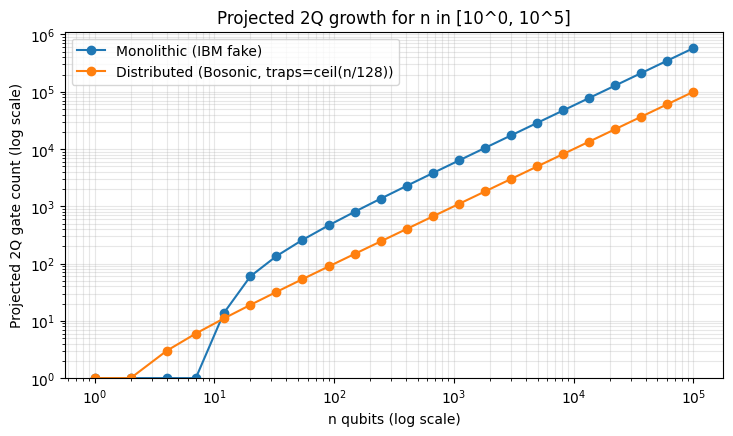

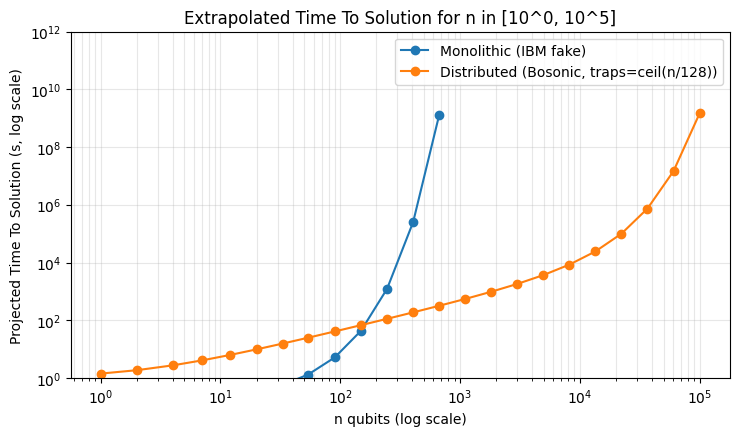

Extrapolation truncation notes (overflow/instability guardrail):
 - Monolithic (IBM fake): truncated at n >= 1105
Values beyond these cutoffs are omitted from the plot to avoid numerical overflow errors


In [19]:
if df_proj.empty:
    raise RuntimeError('df_proj is missing or empty. Run the extrapolation-fit cell first.')
_scenario_labels = {'monolithic': 'Monolithic (IBM fake)', 'distributed': 'Distributed (Bosonic, traps=ceil(n/128))'}
scenarios_present = [s for s in df_proj['scenario'].dropna().unique().tolist()]
plt.figure(figsize=(8.5, 4.5))
for _scenario in scenarios_present:
    prj = df_proj[df_proj['scenario'] == _scenario].sort_values('n')
    y = prj['N2_hat'].replace([np.inf, -np.inf], np.nan)
    y = y.clip(lower=1.0)
    m = np.isfinite(y) & np.isfinite(prj['n'])
    if m.any():
        plt.plot(prj.loc[m, 'n'], y[m], marker='o', label=_scenario_labels.get(_scenario, _scenario))
plt.xscale('log')
plt.yscale('log')
plt.ylim(bottom=1.0)
plt.xlabel('n qubits (log scale)')
plt.ylabel('Projected 2Q gate count (log scale)')
plt.title('Projected 2Q growth for n in [10^0, 10^5]')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()
plt.figure(figsize=(8.5, 4.5))
cutoff_notes = []
for _scenario in scenarios_present:
    prj = df_proj[df_proj['scenario'] == _scenario].sort_values('n').copy()
    y = prj['TTS_shots_hat'].replace([np.inf, -np.inf], np.nan)
    valid = np.isfinite(y) & np.isfinite(prj['n']) & (y > 0) & (y <= TTS_PLOT_MAX) & (y <= 1000000000000.0)
    if valid.any():
        x_ok = prj.loc[valid, 'n']
        y_ok = y[valid]
        plt.plot(x_ok, y_ok, marker='o', label=_scenario_labels.get(_scenario, _scenario))
    invalid = ~np.isfinite(y) | (y <= 0) | (y > TTS_PLOT_MAX) | (y > 1000000000000.0)
    if invalid.any():
        n_cut = int(prj.loc[invalid, 'n'].iloc[0])
        cutoff_notes.append(f'{_scenario_labels.get(_scenario, _scenario)}: truncated at n >= {n_cut}')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1.0, 1000000000000.0)
plt.xlabel('n qubits (log scale)')
plt.ylabel('Projected Time To Solution (s, log scale)')
plt.title('Extrapolated Time To Solution for n in [10^0, 10^5]')
plt.grid(True, which='both', alpha=0.3)
plt.legend()
plt.show()
if cutoff_notes:
    print('Extrapolation truncation notes (overflow/instability guardrail):')
    for note in cutoff_notes:
        print(' -', note)
    print('Values beyond these cutoffs are omitted from the plot to avoid numerical overflow errors')


# Interpreting the Results

These projections highlight a key scaling challenge for monolithic approaches.

At small sizes, monolithic circuits with fast native gates can outperform distributed ones by far. As size grows, routing overhead in nearest-neighbor architectures creates fast growth in two-qubit costs and greatly imparcting Time-To-Solution. This is a key challenge monolithic approaches face and why as we try to scale to useful qubit counts the industry is turning to distributed quantum computing.

Distributed systems introduce their own challenges (for example remote entanglement and coordination overhead), but they provide a practical path to larger effective system sizes.


--------------------------------------------------------------------------------------------------------------------------------------

# Distributing Circuits

In this notebook we explored how scaling quantum circuits scale between monolithic and distributed architectures stricly in terms of gate counts. However, we neglected one of the biggest advantages that distributed systems have, their ability to run computations in parallel on different modules/QPUs. One can also use this ability to run computations in parallel to run different parts of a circuit at the same time! This is one of the biggest advantages of distributed quantum computing but implementation is not as trivial as one may think. Refer back to the slides to learn more!


--------------------------------------------------------------------------------------------------------------------------------------

# Try it Yourself!

You may have noticed that the scaling behaviour for our circuits had the same shape across different metrics. This was due to our choice of using GHZ circuits. As we scaled up we added two exactly one CNOT which made all of our scaling trivial. Below is a sandbox where you can design your own circuit and use all of the tools we have defined to explore scaling using your own circuit!

Start in the cell below by defining your circuit! The only requirement is to add some dependency on the number of qubits (n) so that your circuit has some sort of scaling and is compatabile with all of our functions! This is left as an excercise for your own time or if you get through the notebook earlier than others!


--------------------------------------------------------------------------------------------------------------------------------------
# Try It Yourself: Build Your Own Scaling Experiment


In [20]:
YOUR_N_LIST = [9, 18, 27, 36, 45]
YOUR_N_EXTRAP = np.unique(np.logspace(0, 5, 24).astype(int)).tolist()
YOUR_BOSONIC_QUBITS_PER_MODULE = QUBITS_PER_TRAP_1

# Default is a Shor 9 Qubit error correcting circuit 
def circuit_fn(n: int):
    if n % 9 != 0 or n < 9:
        raise ValueError('Use n as a positive multiple of 9 (e.g., 9, 18, 27, ...).')
    _qc = QuantumCircuit(n, n)
    n_blocks = n // 9
    for b in range(n_blocks):
        o = 9 * b
        _qc.cx(o + 0, o + 3)
        _qc.cx(o + 0, o + 6)
        _qc.h(o + 0)
        _qc.h(o + 3)
        _qc.h(o + 6)
        for r in [o + 0, o + 3, o + 6]:
            _qc.cx(r, r + 1)
            _qc.cx(r, r + 2)
    _qc.measure(range(n), range(n))
    return _qc


In [21]:
## These are a list of available metrics to plot, you do not need to edit this cell it serves only as a library of available metrics. 

YOUR_METRIC_REGISTRY = {
    'depth': lambda s, g, q: s['depth'],
    'two_qubit_depth': lambda s, g, q: q['two_qubit_depth'],
    'two_qubit_count': lambda s, g, q: q['two_qubit_count'],
    'single_qubit_count': lambda s, g, q: q['single_qubit_count'],
    'total_ops': lambda s, g, q: s['total_ops'],
    'measure_count': lambda s, g, q: q['measure_count'],
    'reset_count': lambda s, g, q: q['reset_count'],
    'remote_link_count': lambda s, g, q: g.get('remote_link_psi_minus', 0) + g.get('remote_link_psi_plus', 0),
    'local_gate_count': lambda s, g, q: s['local_gate_count'],
    'remote_gate_count': lambda s, g, q: s['remote_gate_count'],
    'qubit_teleportation_count': lambda s, g, q: s['qubit_teleportation_count'],
}
YOUR_METRIC_LABELS = {
    'depth': 'Depth',
    'two_qubit_depth': 'Two-Qubit Layer Depth',
    'two_qubit_count': 'Two-Qubit Gate Count',
    'single_qubit_count': 'Single-Qubit Gate Count',
    'total_ops': 'Total Ops',
    'measure_count': 'Measurement Count',
    'reset_count': 'Reset Count',
    'remote_link_count': 'Remote Link Count',
    'local_gate_count': 'Local Gate Count',
    'remote_gate_count': 'Remote Gate Count',
    'qubit_teleportation_count': 'Qubit Teleportation Count',
}


In [22]:
# Here you can adjust the list "YOUR_METRICS_TO_PLOT" to choose which metrics you would like to plot! 
YOUR_METRICS_TO_PLOT = ['two_qubit_count', 'total_ops']




AVAILABLE_METRICS = list(YOUR_METRIC_REGISTRY.keys())
for metric in YOUR_METRICS_TO_PLOT:
    if metric not in AVAILABLE_METRICS:
        raise ValueError(f'Unknown metric selected for plotting: {metric}')
YOUR_PLOT_METRIC_PAIRS = [(metric, YOUR_METRIC_LABELS[metric]) for metric in YOUR_METRICS_TO_PLOT]

def your_module_count(n, qubits_per_module=YOUR_BOSONIC_QUBITS_PER_MODULE):
    return module_count(n, qubits_per_module)

def extract_your_metrics(qc, metric_keys=YOUR_METRICS_TO_PLOT):
    metric_pairs = [(metric, YOUR_METRIC_LABELS[metric]) for metric in metric_keys]
    return extract_metrics(qc, YOUR_METRIC_REGISTRY, metric_pairs)


In [23]:
your_rows = []
for _n in YOUR_N_LIST:
    _qc = circuit_fn(_n)
    _qc_mono = compile_monolithic_ibm_fake(_qc)
    _m_mono = extract_your_metrics(_qc_mono)
    your_rows.append({
        **build_tts_row(_n, 'monolithic', 1, qc_comp=_qc_mono),
        **_m_mono,
    })
    _k_dist = your_module_count(_n)
    qc_dist = compile_bosonic(_qc, _n, _k_dist)
    m_dist = extract_your_metrics(qc_dist)
    your_rows.append({
        **build_tts_row(_n, 'distributed', _k_dist, qc_comp=qc_dist),
        'label': f'Distributed (Bosonic, k=ceil(n/{YOUR_BOSONIC_QUBITS_PER_MODULE}))',
        **m_dist,
    })
df_your = pd.DataFrame(your_rows)


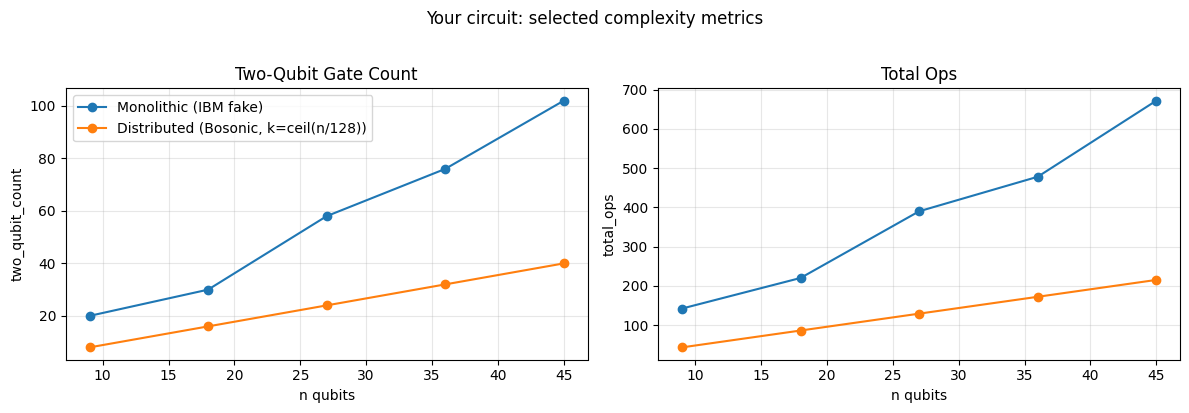

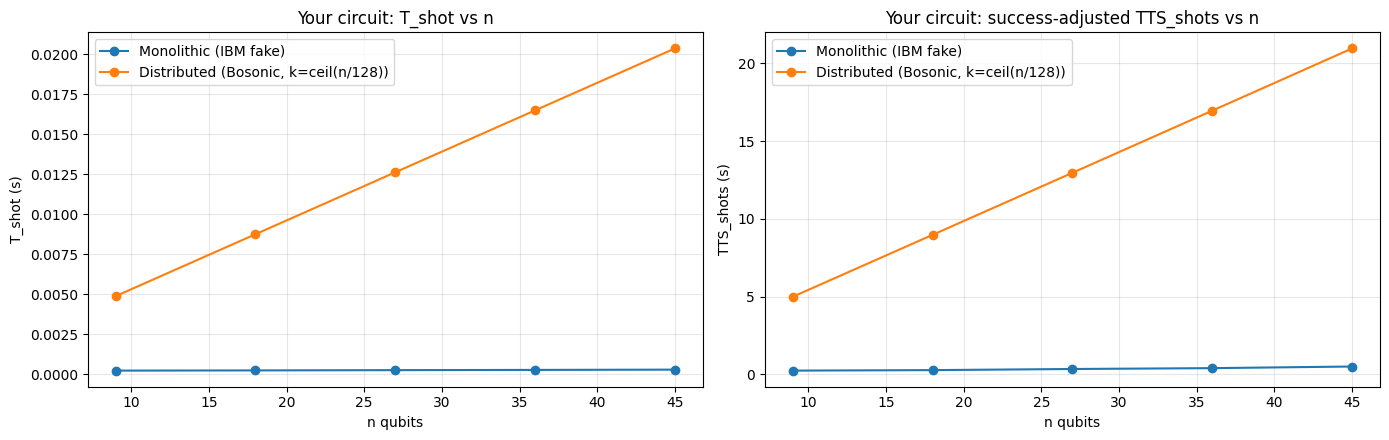

In [24]:
plot_metric_grid(
    df_your,
    metric_pairs=YOUR_PLOT_METRIC_PAIRS,
    scenario_order=['monolithic', 'distributed'],
    scenario_labels={
        'monolithic': 'Monolithic (IBM fake)',
        'distributed': df_your[df_your['scenario'] == 'distributed'].sort_values('n')['label'].iloc[0],
    },
    title='Your circuit: selected complexity metrics',
    y_label_mode='metric',
)
plot_two_series_by_scenario(
    df_your,
    scenario_order=['monolithic', 'distributed'],
    scenario_labels={
        'monolithic': 'Monolithic (IBM fake)',
        'distributed': df_your[df_your['scenario'] == 'distributed'].sort_values('n')['label'].iloc[0],
    },
    left_col='T_shot',
    right_col='TTS_shots',
    left_title='Your circuit: T_shot vs n',
    right_title='Your circuit: success-adjusted TTS_shots vs n',
    left_ylabel='T_shot (s)',
    right_ylabel='TTS_shots (s)',
)


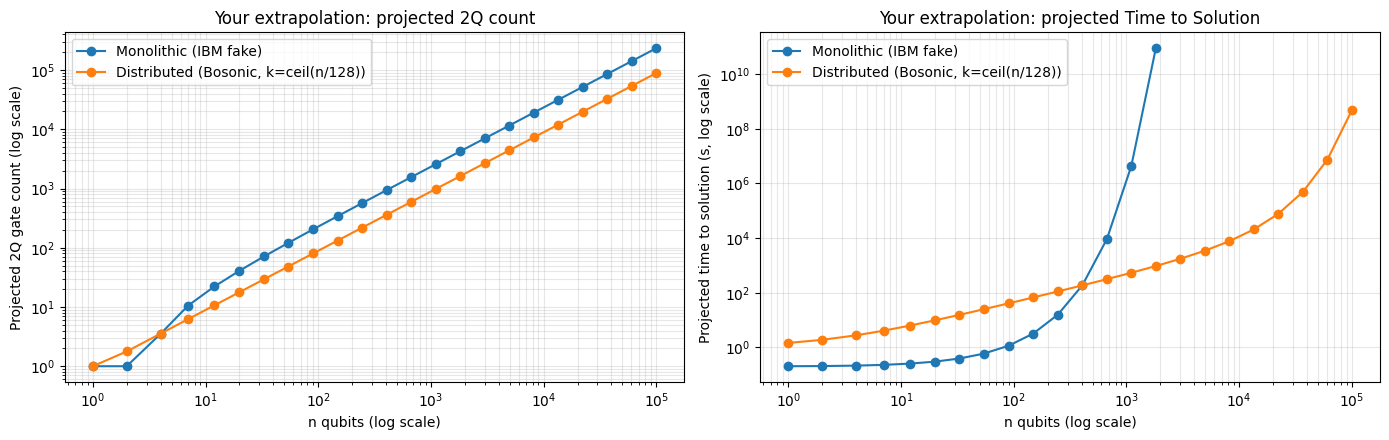

In [25]:
_proj_rows = []
for _scenario in ['monolithic', 'distributed']:
    _sub = df_your[df_your['scenario'] == _scenario].sort_values('n')
    _p1 = fit_linear(_sub['n'], _sub['N1'])
    _p2 = fit_linear(_sub['n'], _sub['N2'])
    _pm = fit_linear(_sub['n'], _sub['N_meas'])
    _n_proj = np.asarray(YOUR_N_EXTRAP, dtype=float)
    _n1_proj = np.maximum(predict_linear(_n_proj, _p1), 0.0)
    _n2_proj = np.maximum(predict_linear(_n_proj, _p2), 0.0)
    _nm_proj = np.maximum(predict_linear(_n_proj, _pm), 0.0)
    for _n_val, _n1_hat, _n2_hat, _nm_hat in zip(_n_proj, _n1_proj, _n2_proj, _nm_proj):
        _k_modules = 1 if _scenario == 'monolithic' else your_module_count(_n_val)
        _p_succ_hat = shot_success_probability(_n1_hat, _n2_hat, scenario=_scenario)
        _t_shot_hat = T_shot_from_counts(_n1_hat, _n2_hat, N_meas=_nm_hat, scenario=_scenario)
        _tts_hat = TTS_from_shots(_t_shot_hat, p_success=_p_succ_hat, shots=SHOTS_2)
        _proj_rows.append({'n': int(_n_val), 'scenario': _scenario, 'N2_hat': float(_n2_hat), 'TTS_shots_hat': float(_tts_hat)})
df_your_proj = pd.DataFrame(_proj_rows)
_fig, _axes = plt.subplots(1, 2, figsize=(14, 4.5))
for _scenario in ['monolithic', 'distributed']:
    _sub = df_your_proj[df_your_proj['scenario'] == _scenario].sort_values('n')
    _label = 'Monolithic (IBM fake)' if _scenario == 'monolithic' else f'Distributed (Bosonic, k=ceil(n/{YOUR_BOSONIC_QUBITS_PER_MODULE}))'
    y_n2 = _sub['N2_hat'].replace([np.inf, -np.inf], np.nan).clip(lower=1.0)
    m_n2 = np.isfinite(y_n2)
    _axes[0].plot(_sub.loc[m_n2, 'n'], y_n2[m_n2], marker='o', label=_label)
    y_tts = _sub['TTS_shots_hat'].replace([np.inf, -np.inf], np.nan)
    m_tts = np.isfinite(y_tts) & (y_tts > 0) & (y_tts <= TTS_PLOT_MAX)
    _axes[1].plot(_sub.loc[m_tts, 'n'], y_tts[m_tts], marker='o', label=_label)
_axes[0].set_xscale('log')
_axes[0].set_yscale('log')
_axes[0].set_title('Your extrapolation: projected 2Q count')
_axes[0].set_xlabel('n qubits (log scale)')
_axes[0].set_ylabel('Projected 2Q gate count (log scale)')
_axes[0].grid(True, which='both', alpha=0.3)
_axes[0].legend()
_axes[1].set_xscale('log')
_axes[1].set_yscale('log')
_axes[1].set_title('Your extrapolation: projected Time to Solution')
_axes[1].set_xlabel('n qubits (log scale)')
_axes[1].set_ylabel('Projected time to solution (s, log scale)')
_axes[1].grid(True, which='both', alpha=0.3)
_axes[1].legend()
plt.tight_layout()
plt.show()
